upper_bound: 64.38


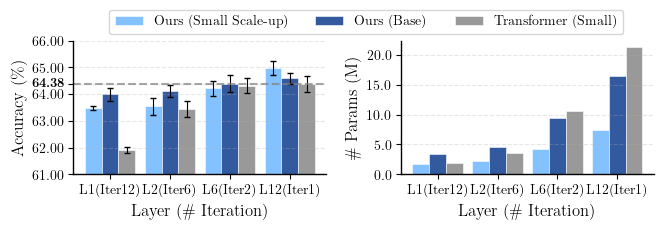

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Set global matplotlib parameters for consistency
plt.rcParams.update(
    {
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Times New Roman"],
        "font.size": 12,  # default 14
        "axes.labelsize": 12,  # default 14
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "font.family": "Times New Roman",
        "grid.alpha": 0.3,
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
    }
)

# Data
categories = ["L1(Iter12)", "L2(Iter6)", "L6(Iter2)", "L12(Iter1)"]

# old setting (CIFAR-10)

# ours_small_scaleup = [85.27, 85.58, 86.13, 86.09]  # dim512/head8
# ours_base = [85.65, 86.46, 86.49, 87.1]  # dim768/head12
# transformer_small = [84.55, 86.29, 86.34, 86.88]  # dim384/head6
# # Parameters
# ours_small_scaleup_params = [1.97792, 2.50278, 4.60224, 7.75142]  # dim512/head8
# ours_base_params = [3.94912, 5.12960, 9.85152, 16.93440]  # dim768/head12
# transformer_small_params = [2.07245, 3.84269, 10.92365, 21.54509]  # dim384/head6
# upper_bound = 86.88  # Upper bound for accuracy


# new setting (CIFAR-100)

ours_small_scaleup = [63.49, 63.54, 64.22, 64.98]  # dim512/head8
# transformer_small = [61.89, 64.44, 64.24, 62.88]  # dim384/head6
# transformer_small = [61.77, 62.12, 65.12, 63.39]  # dim384/head6/replace layernorm with rmsnorm
transformer_small = [61.90, 63.45, 64.32, 64.38]  # dim384/head6/keep layernorm
# ours_base = [85.82, 86.02, 86.05, 86.68] # dim640/head10
# ours_base = [64.06, 64.42, 62.97, 64.13]  # dim768/head12
ours_base = [63.99, 64.11, 64.40, 64.60]  # dim768/head12/remove rms in the second time mlp

ours_small_scaleup_params = [1.66, 2.18, 4.28, 7.43]  # dim512/head8
# transformer_small_params = [1.83, 3.60, 10.68, 21.31]  # dim384/head6/replace layernorm with rmsnorm
transformer_small_params = [1.83, 3.60, 10.68, 21.31]  # dim384/head6/keep layernorm
# ours_base_params = [2.88160, 3.70150, 6.98112, 11.90054]  # dim640/head10
# ours_base_params = [3.47, 4.65, 9.37, 16.46]  # dim768/head12
ours_base_params = [3.47, 4.65, 9.37, 16.46]  # dim768/head12/remove rms in the second time mlp

# std_ours_small_scaleup = [0.0653, 0.5162,0.4769, 0.3589]
std_ours_small_scaleup = [0.0653, 0.3162, 0.2769, 0.2589]  # reduce a little

# std_transformer_small = [0.1110,0.4137, 0.3696, 0.3918]
std_transformer_small = [0.1110, 0.3137, 0.2696, 0.2918]  # reduce a little

# std_ours_base = [0.2401, 0.4324, 0.5332, 0.2078]
std_ours_base = [0.2401, 0.2324, 0.3332, 0.2078]  # reduce a little

upper_bound = max(transformer_small)  # Upper bound value
print("upper_bound:", upper_bound)

cmap = LinearSegmentedColormap.from_list("ours_gradient", ["#66b3ff", "#003087"])  # Light to dark blue
ours_colors = [cmap(i / 1.0) for i in range(2)]  # Two shades for Ours models

transformer_color = "gray"

color_map = {
    "Ours (Small Scale-up)": ours_colors[0],
    "Ours (Base)": ours_colors[1],
    "Transformer (Small)": transformer_color,
}


# Helper function to plot bars
def plot_bars(ax, x, data_list, labels, bar_width, offset, yerr=None):
    if yerr is not None:
        for i, (data, label, err) in enumerate(zip(data_list, labels, yerr)):
            ax.bar(
                x + (i - 1) * bar_width + offset,
                data,
                width=bar_width,
                label=label,
                color=color_map[label],
                alpha=0.8,
                edgecolor="white",
                linewidth=0.5,
                # yerr=err,
                # capsize=2,
            )
            ax.errorbar(
                x + (i - 1) * bar_width + offset,
                data,
                yerr=err,
                fmt="none",
                color="black",
                capsize=2,
                elinewidth=0.8,
            )
    else:
        for i, (data, label) in enumerate(zip(data_list, labels)):
            ax.bar(
                x + (i - 1) * bar_width + offset,
                data,
                width=bar_width,
                label=label,
                color=color_map[label],
                alpha=0.8,
                edgecolor="white",
                linewidth=0.5,
            )


# Set up figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.8, 2.2), sharex=True)  # (7, 2.8)

# X-axis positions and bar width
x = np.arange(len(categories))
bar_width = 0.28

# Plot accuracy (left subplot)
plot_bars(
    ax1,
    x,
    [ours_small_scaleup, ours_base, transformer_small],
    ["Ours (Small Scale-up)", "Ours (Base)", "Transformer (Small)"],
    bar_width,
    0,
    yerr=[std_ours_small_scaleup, std_ours_base, std_transformer_small],
)

# Add upper bound line
ax1.axhline(y=upper_bound, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

# Set y-axis limits dynamically
min_acc = min(min(ours_small_scaleup), min(ours_base), min(transformer_small))
max_acc = max(max(ours_small_scaleup), max(ours_base), max(transformer_small), upper_bound)
ax1.set_ylim(min_acc - 0.5, max_acc + 0.5)


yticks = ax1.get_yticks()
if not np.any(np.isclose(yticks, upper_bound, atol=0.1)):  # Add upper bound if not close
    yticks = np.append(yticks, upper_bound)
    yticks = np.sort(yticks)

# Set y-ticks but exclude upper bound from default labels to avoid overlap
ax1.set_yticks(yticks)
ax1.set_yticklabels([f"{val:.2f}" if not np.isclose(val, upper_bound, atol=0.01) else "" for val in yticks])

# Add custom upper bound label with offset
ax1.text(
    -0.03,
    upper_bound - 0.2,  # Slight offset in x and y
    r"\textbf{64.38}",
    transform=ax1.get_yaxis_transform(),  # Use y-axis coordinate system
    ha="right",
    va="bottom",
    fontsize=9,
)

# Plot parameters (right subplot)
plot_bars(
    ax2,
    x,
    [ours_small_scaleup_params, ours_base_params, transformer_small_params],
    ["Ours (Small Scale-up)", "Ours (Base)", "Transformer (Small)"],
    bar_width,
    0,
)

# Set y-ticks for ax2 with interval of 5
min_params = min(min(ours_small_scaleup_params), min(ours_base_params), min(transformer_small_params))
max_params = max(max(ours_small_scaleup_params), max(ours_base_params), max(transformer_small_params))
yticks_params = np.arange(0, max_params, 5)  # Interval of 5
ax2.set_yticks(yticks_params)
ax2.set_yticklabels([f"{val:.1f}" for val in yticks_params])

# Set labels
ax1.set_xlabel(r"Layer (\# Iteration)")
ax1.set_ylabel(r"Accuracy (\%)")
ax2.set_xlabel(r"Layer (\# Iteration)")
ax2.set_ylabel(r"\# Params (M)")

# Set x-ticks
for ax in (ax1, ax2):
    ax.set_xticks(x)
    ax.set_xticklabels(categories)

# Add legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.55, 1.07),  # (0.55, 1.05)
    ncol=3,
    frameon=True,
)

# Remove top and right spines
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax1.grid(axis="x")  # Add light dashed grid lines for y-axis
ax2.grid(axis="x")

# Adjust layout
plt.tight_layout()

# Save and show
plt.savefig("bar_plot_with_upper_bound.pdf", bbox_inches="tight", dpi=600)
plt.show()